# MAMMAL Model Inference Notebook

Run inference with a finetuned MAMMAL model on **any CSV file** containing SMILES strings.

**Fully self-contained** — no `ligand_ai` package import, no subprocess, no Hydra, no train/val files needed.

## Steps
0. Configuration (edit paths here)
1. Preview input data
2. Load tokenizer
3. Load model
4. Build DataLoader (inline — no train/val needed)
5. Run inference (inline predict loop)
6. Inspect predictions
7. Evaluate (if labels available)
8. Top hits
9. Save hits above threshold

In [1]:
!pip install biomed-multi-alignment

In [2]:
def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False
IS_GOOGLE_COLAB = is_colab()
print(f"{IS_GOOGLE_COLAB=}")

IS_GOOGLE_COLAB=False


## 0. Configuration

**Edit the three paths below before running.**

In [12]:
import os

# ── USER SETTINGS ─────────────────────────────────────────────────────────────

# Path to a CSV/TSV file with SMILES (and optionally labels)
if IS_GOOGLE_COLAB:
    MODEL_PATH ="michalozeryflato/biomed.omics.bl.sm.ma-ted-458m.wdr91"
    DATA_PATH = "/content/test.csv"
    OUTPUT_PATH = "/content/predictions/mammal_notebook_wdr91_test.csv"

else:
    MODEL_PATH = "/proj/ligand_ai/models/wdr91_ASMS_train_val_v1/mammal/last.ckpt"
    DATA_PATH = "/proj/ligand_ai/datasets_manager/processed/splits/wdr91_ASMS_train_val_v1/test.csv"
    OUTPUT_PATH = "/proj/ligand_ai/users/ozery/mammal_notebook_wdr91_predictions.csv"

# Column names in the input CSV
SMILES_COLUMN = "smiles"
LABEL_COLUMN  = "label"   # set to None if the file has no labels

# Target / assay (must match training)
TARGET_NAME = "WDR91"
ASSAY_TYPE  = "ASMS"

# Special tokens added during training
NEW_SPECIAL_TOKENS = ["<PGK2_ASMS>", "<WDR91_ASMS>"]

# Base MAMMAL tokenizer / model (HuggingFace hub id or local path)
BASE_MODEL_PATH = "ibm/biomed.omics.bl.sm.ma-ted-458m"

# Inference device
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# DataLoader settings
BATCH_SIZE             = 128
DRUG_MAX_SEQ_LENGTH    = 300
ENCODER_INPUT_MAX_LEN  = 320
LABELS_MAX_LEN         = 10
NUM_WORKERS            = 0

# ── VALIDATION ────────────────────────────────────────────────────────────────
# MICHAL
assert os.path.exists(MODEL_PATH), f"Model not found: {MODEL_PATH}"
assert os.path.exists(DATA_PATH),  f"Data not found:  {DATA_PATH}"
os.makedirs(os.path.dirname(OUTPUT_PATH) or ".", exist_ok=True)

print(f"Model : {MODEL_PATH}")
print(f"Data  : {DATA_PATH}")
print(f"Output: {OUTPUT_PATH}")
print(f"Device: {DEVICE}")

Model : /proj/ligand_ai/models/wdr91_ASMS_train_val_v1/mammal/last.ckpt
Data  : /proj/ligand_ai/datasets_manager/processed/splits/wdr91_ASMS_train_val_v1/test.csv
Output: /proj/ligand_ai/users/ozery/mammal_notebook_wdr91_predictions.csv
Device: cuda


## 1. Preview Input Data

In [4]:
import pandas as pd

sep = "\t" if DATA_PATH.endswith(".tsv") else ","
input_df = pd.read_csv(DATA_PATH, sep=sep)

print(f"Shape  : {input_df.shape}")
print(f"Columns: {list(input_df.columns)}")

if LABEL_COLUMN and LABEL_COLUMN in input_df.columns:
    print(f"\nLabel distribution:")
    print(input_df[LABEL_COLUMN].value_counts().sort_index())

input_df.head()

Shape  : (234, 2)
Columns: ['smiles', 'label']

Label distribution:
label
0    176
1     58
Name: count, dtype: int64


,smiles,label
0,COC(=O)CC(NC(=O)c1ccc(Cn2cncn2)cc1)c1ccc(Cl)cc1,1
1,NC(=O)C[C@@H](NC(=O)c1ccc(N2CCC(O)C2)cc1)c1ccc...,1
2,COC(=O)CC(NC(=O)c1ccc(CN2C(=O)CCC2=O)cc1)c1ccc...,1
3,O=C(NC(CO)c1ccc(Cl)cc1)c1ccc(N2CCC(O)C2)cc1,1
4,CN(C)Cc1ccc(C(=O)NC(c2ccccc2)c2ccc(Cl)cc2)cn1,1


## 2. Load Tokenizer

In [5]:
import os, sys, contextlib, tempfile

@contextlib.contextmanager
def redirect_fds(stdout=True, stderr=True):
    to_restore, temps = [], []
    try:
        if stdout:
            saved = os.dup(1)
            to_restore.append((1, saved))
            f = tempfile.TemporaryFile(mode='w+b'); temps.append(f)
            os.dup2(f.fileno(), 1)
        if stderr:
            saved = os.dup(2)
            to_restore.append((2, saved))
            f = tempfile.TemporaryFile(mode='w+b'); temps.append(f)
            os.dup2(f.fileno(), 2)
        yield
    finally:
        try: sys.stdout.flush(); sys.stderr.flush()
        except Exception: pass
        for fd, saved in reversed(to_restore):
            os.dup2(saved, fd); os.close(saved)
        for f in temps:
            try: f.close()
            except Exception: pass

In [6]:
with redirect_fds(stdout=True, stderr=True):
    from fuse.data.tokenizers.modular_tokenizer.op import ModularTokenizerOp

    print(f"Loading tokenizer from: {BASE_MODEL_PATH}")
    tokenizer_op = ModularTokenizerOp.from_pretrained(BASE_MODEL_PATH)

    if NEW_SPECIAL_TOKENS:
        num_added = tokenizer_op.add_new_special_tokens(NEW_SPECIAL_TOKENS)
        if num_added:
            print(f"Added {num_added} special tokens: {NEW_SPECIAL_TOKENS}")
        else:
            print(f"Special tokens already present: {NEW_SPECIAL_TOKENS}")

print("Tokenizer ready.")

Loading tokenizer from: ibm/biomed.omics.bl.sm.ma-ted-458m


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Added 2 special tokens: ['<PGK2_ASMS>', '<WDR91_ASMS>']
Tokenizer ready.


## 3. Load Model

In [7]:
from mammal.model import Mammal

print(f"Loading base MAMMAL from: {BASE_MODEL_PATH}")
base_model = Mammal.from_pretrained(BASE_MODEL_PATH)

2026-03-02 14:04:12.600625: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/proj/bmfm/users/ozery/miniforge3/envs/fuse4/lib/python3.11/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/proj/bmfm/users/ozery/miniforge3/envs/fuse4/lib/python3.11/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compati

Loading base MAMMAL from: ibm/biomed.omics.bl.sm.ma-ted-458m
Path doesn't exist. Will try to download from hf hub. pretrained_model_name_or_path='ibm/biomed.omics.bl.sm.ma-ted-458m'


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Attempting to load model from dir: pretrained_model_name_or_path='/u/ozery/.cache/huggingface/hub/models--ibm--biomed.omics.bl.sm.ma-ted-458m/snapshots/6d319d8dcf97f8821635327fc8cda24670553daa'


In [8]:
from fuse.dl.lightning.pl_module import LightningModuleDefault

model_dir = None
if os.path.exists(MODEL_PATH):
    if os.path.isdir(MODEL_PATH):
        model_dir = MODEL_PATH
        checkpoint_path = None
    else:
      checkpoint_path = MODEL_PATH
else:
    from huggingface_hub import hf_hub_download
    checkpoint_path = hf_hub_download(
        repo_id=MODEL_PATH,
        filename="last.ckpt",
        revision="main"
    )
   
print(f"{checkpoint_path=}")
pl_module = LightningModuleDefault.load_from_checkpoint(
    checkpoint_path=checkpoint_path,
    model_dir=model_dir,
    model=base_model,
    map_location="cpu",
)
model = pl_module._model
model.eval()
model = model.to(DEVICE)
print(f"\nModel ready on {DEVICE}.")

/proj/bmfm/users/ozery/miniforge3/envs/fuse4/lib/python3.11/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


checkpoint_path='/proj/ligand_ai/models/wdr91_ASMS_train_val_v1/mammal/last.ckpt'


/proj/bmfm/users/ozery/miniforge3/envs/fuse4/lib/python3.11/site-packages/lightning_fabric/utilities/cloud_io.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return tor


Model ready on cuda.


## 4. Build DataLoader

All preprocessing code is inlined here — no `ligand_ai` import needed, no train/val files required.

In [10]:
from functools import partial
from torch.utils.data import Dataset, DataLoader
from fuse.data.utils.collates import CollateDefault
from mammal.keys import (
    CLS_PRED, SCORES,
    ENCODER_INPUTS_STR, ENCODER_INPUTS_TOKENS, ENCODER_INPUTS_ATTENTION_MASK,
    LABELS_STR, LABELS_TOKENS, LABELS_ATTENTION_MASK,
    DECODER_INPUTS_STR, DECODER_INPUTS_TOKENS, DECODER_INPUTS_ATTENTION_MASK,
)

# ── Inline dataset ─────────────────────────────────────────────────────────────
class InferenceDataset(Dataset):
    """
    Simple dataset for inference from a single CSV/TSV file.
    No train/val files needed.
    """
    def __init__(self, df, smiles_column, label_column, tokenizer_op,
                 target_name, assay_type,
                 drug_max_seq_length, encoder_input_max_seq_len, labels_max_seq_len):
        self.smiles = df[smiles_column].tolist()
        self.has_labels = label_column is not None and label_column in df.columns
        self.labels = df[label_column].tolist() if self.has_labels else [None] * len(df)
        self.indices = df.index.tolist()
        self.tokenizer_op = tokenizer_op
        self.target_name = target_name.upper()
        self.assay_type = assay_type.upper()
        self.drug_max_seq_length = drug_max_seq_length
        self.encoder_input_max_seq_len = encoder_input_max_seq_len
        self.labels_max_seq_len = labels_max_seq_len
        print(f"InferenceDataset: {len(self.smiles)} samples, has_labels={self.has_labels}")

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        drug_sequence = self.smiles[idx]
        label = self.labels[idx]
        task_identifier = f"{self.target_name}_{self.assay_type}"

        sample = {
            "index": self.indices[idx],
            "data.smiles": drug_sequence,
            "data.label": label,
        }

        # Encoder input
        sample[ENCODER_INPUTS_STR] = (
            f"<@TOKENIZER-TYPE=SMILES><{task_identifier}><SENTINEL_ID_0>"
            f"<MOLECULAR_ENTITY><MOLECULAR_ENTITY_SMALL_MOLECULE>"
            f"<@TOKENIZER-TYPE=SMILES@MAX-LEN={self.drug_max_seq_length}>"
            f"<SEQUENCE_NATURAL_START>{drug_sequence}<SEQUENCE_NATURAL_END><EOS>"
        )
        self.tokenizer_op(
            sample_dict=sample,
            key_in=ENCODER_INPUTS_STR,
            key_out_tokens_ids=ENCODER_INPUTS_TOKENS,
            key_out_attention_mask=ENCODER_INPUTS_ATTENTION_MASK,
            max_seq_len=self.encoder_input_max_seq_len,
        )
        sample[ENCODER_INPUTS_TOKENS] = torch.tensor(sample[ENCODER_INPUTS_TOKENS])
        sample[ENCODER_INPUTS_ATTENTION_MASK] = torch.tensor(sample[ENCODER_INPUTS_ATTENTION_MASK])

        # Labels (only if available — needed for decoder input during inference too)
        if label is not None:
            pad_id = self.tokenizer_op.get_token_id("<PAD>")
            ignore_token_value = -100

            sample[LABELS_STR] = f"<@TOKENIZER-TYPE=SMILES><SENTINEL_ID_0><{label}><EOS>"
            self.tokenizer_op(
                sample_dict=sample,
                key_in=LABELS_STR,
                key_out_tokens_ids=LABELS_TOKENS,
                key_out_attention_mask=LABELS_ATTENTION_MASK,
                max_seq_len=self.labels_max_seq_len,
            )
            sample[LABELS_TOKENS] = torch.tensor(sample[LABELS_TOKENS])
            sample[LABELS_ATTENTION_MASK] = torch.tensor(sample[LABELS_ATTENTION_MASK])
            sample[LABELS_TOKENS][
                (sample[LABELS_TOKENS][..., None] == torch.tensor(pad_id)).any(-1).nonzero()
            ] = ignore_token_value

            sample[DECODER_INPUTS_STR] = f"<@TOKENIZER-TYPE=SMILES><DECODER_START><SENTINEL_ID_0><{label}><EOS>"
            self.tokenizer_op(
                sample_dict=sample,
                key_in=DECODER_INPUTS_STR,
                key_out_tokens_ids=DECODER_INPUTS_TOKENS,
                key_out_attention_mask=DECODER_INPUTS_ATTENTION_MASK,
                max_seq_len=self.labels_max_seq_len,
            )
            sample[DECODER_INPUTS_TOKENS] = torch.tensor(sample[DECODER_INPUTS_TOKENS])
            sample[DECODER_INPUTS_ATTENTION_MASK] = torch.tensor(sample[DECODER_INPUTS_ATTENTION_MASK])

        return sample


# ── Build DataLoader ───────────────────────────────────────────────────────────
pad_token_id = tokenizer_op.get_token_id("<PAD>")
special_handlers = {
    ENCODER_INPUTS_TOKENS: partial(CollateDefault.crop_padding, pad_token_id=pad_token_id),
    ENCODER_INPUTS_ATTENTION_MASK: partial(CollateDefault.crop_padding, pad_token_id=False),
}

dataset = InferenceDataset(
    df=input_df,
    smiles_column=SMILES_COLUMN,
    label_column=LABEL_COLUMN,
    tokenizer_op=tokenizer_op,
    target_name=TARGET_NAME,
    assay_type=ASSAY_TYPE,
    drug_max_seq_length=DRUG_MAX_SEQ_LENGTH,
    encoder_input_max_seq_len=ENCODER_INPUT_MAX_LEN,
    labels_max_seq_len=LABELS_MAX_LEN,
)

dataloader = DataLoader(
    dataset=dataset,
    batch_size=BATCH_SIZE,
    collate_fn=CollateDefault(special_handlers_keys=special_handlers),
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print(f"DataLoader ready: {len(dataset)} samples, {len(dataloader)} batches")

InferenceDataset: 234 samples, has_labels=True
DataLoader ready: 234 samples, 2 batches


## 5. Run Inference

Inline predict loop — no `LigandTargetTask` import needed.

In [ ]:
import numpy as np
from tqdm.notebook import tqdm

negative_token_id = tokenizer_op.get_token_id("<0>")
positive_token_id = tokenizer_op.get_token_id("<1>")
CLASSIFICATION_POSITION = 1  # position in decoder output where class token appears

results = {
    "sample_id": [],
    "smiles": [],
    "true_label": [],
    "predicted_label": [],
    "prediction_score": [],
    "raw_score_negative": [],
    "raw_score_positive": [],
}

model.eval()
model = model.to(DEVICE)

with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(dataloader, desc="Inference")):
        batch_size = batch[ENCODER_INPUTS_TOKENS].shape[0]

        # Build list of per-sample dicts for model.generate()
        sample_dicts = []
        for i in range(batch_size):
            sd = {}
            for key, value in batch.items():
                if isinstance(value, torch.Tensor):
                    sd[key] = value[i].to(DEVICE)
                elif isinstance(value, list):
                    sd[key] = value[i]
                else:
                    sd[key] = value
            sample_dicts.append(sd)

        # Generate
        batch_out = model.generate(
            sample_dicts,
            output_scores=True,
            return_dict_in_generate=True,
            max_new_tokens=5,
        )

        decoder_output = batch_out.get(CLS_PRED, None)          # (B, seq_len)
        decoder_scores = batch_out.get(SCORES, None)            # (B, seq_len, vocab)

        for i in range(batch_size):
            sample_id  = batch.get("index",      [None] * batch_size)[i]
            smiles     = batch.get("data.smiles", [None] * batch_size)[i]
            true_label = batch.get("data.label",  [None] * batch_size)[i]

            if isinstance(sample_id,  torch.Tensor): sample_id  = sample_id.item()
            if isinstance(true_label, torch.Tensor): true_label = true_label.item()

            if decoder_output is not None and decoder_scores is not None:
                out_tokens = decoder_output[i].cpu().numpy()
                out_scores = decoder_scores[i].cpu().numpy()   # (seq_len, vocab)

                predicted_token = int(out_tokens[CLASSIFICATION_POSITION])
                pos_score = out_scores[CLASSIFICATION_POSITION, positive_token_id]
                neg_score = out_scores[CLASSIFICATION_POSITION, negative_token_id]

                label_map = {negative_token_id: 0, positive_token_id: 1}
                if predicted_token in label_map:
                    predicted_label = label_map[predicted_token]
                else:
                    # Fallback: use scores
                    predicted_label = 1 if pos_score > neg_score else 0

                prediction_score = float(pos_score)
                raw_score_negative = float(neg_score)
                raw_score_positive = float(pos_score)
            else:
                predicted_label = prediction_score = raw_score_negative = raw_score_positive = None

            results["sample_id"].append(sample_id)
            results["smiles"].append(smiles)
            results["true_label"].append(true_label)
            results["predicted_label"].append(predicted_label)
            results["prediction_score"].append(prediction_score)
            results["raw_score_negative"].append(raw_score_negative)
            results["raw_score_positive"].append(raw_score_positive)


Inference:   0%|          | 0/2 [00:00<?, ?it/s]


Saved 234 predictions to: /tmp/mammal_notebook_predictions.csv


In [13]:
predictions_df = pd.DataFrame(results)
predictions_df.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved {len(predictions_df)} predictions to: {OUTPUT_PATH}")


Saved 234 predictions to: /proj/ligand_ai/users/ozery/mammal_notebook_wdr91_predictions.csv


## 6. Inspect Predictions

In [14]:
print(f"Shape: {predictions_df.shape}")
print(f"\nPredicted label distribution:")
print(predictions_df["predicted_label"].value_counts().sort_index())
print(f"\nScore statistics:")
print(predictions_df["prediction_score"].describe())
predictions_df.head(10)

Shape: (234, 7)

Predicted label distribution:
predicted_label
0    231
1      3
Name: count, dtype: int64

Score statistics:
count    2.340000e+02
mean     1.821519e-02
std      1.045230e-01
min      1.043959e-08
25%      4.606656e-08
50%      1.263024e-07
75%      1.493849e-06
max      9.504489e-01
Name: prediction_score, dtype: float64


,sample_id,smiles,true_label,predicted_label,prediction_score,raw_score_negative,raw_score_positive
0,0,COC(=O)CC(NC(=O)c1ccc(Cn2cncn2)cc1)c1ccc(Cl)cc1,1,0,1.446932e-02,0.985530,1.446932e-02
1,1,NC(=O)C[C@@H](NC(=O)c1ccc(N2CCC(O)C2)cc1)c1ccc...,1,0,1.282649e-04,0.999872,1.282649e-04
2,2,COC(=O)CC(NC(=O)c1ccc(CN2C(=O)CCC2=O)cc1)c1ccc...,1,0,1.331936e-03,0.998668,1.331936e-03
3,3,O=C(NC(CO)c1ccc(Cl)cc1)c1ccc(N2CCC(O)C2)cc1,1,0,4.934172e-03,0.995065,4.934172e-03
4,4,CN(C)Cc1ccc(C(=O)NC(c2ccccc2)c2ccc(Cl)cc2)cn1,1,0,1.411089e-02,0.985889,1.411089e-02
5,5,COCCC(NC(=O)c1ccc(N2CCC(O)C2)cc1)c1ccc(Cl)cc1,1,0,5.663169e-07,0.999999,5.663169e-07
6,6,O=C(O)CC(NC(=O)c1ccc(CNC(=O)c2cccs2)cc1)c1ccc(...,1,0,2.744525e-01,0.725545,2.744525e-01
7,7,COC(=O)CC(NC(=O)c1ccc2c(=O)n3c(nc2c1)CCC3)c1cc...,1,0,3.795239e-02,0.962047,3.795239e-02
8,8,COC(=O)CC(NC(=O)c1ccc2c(c1)CCN2C(C)=O)c1ccc(Cl...,1,0,1.827999e-03,0.998172,1.827999e-03
9,9,Cn1ccnc1C(NC(=O)c1ccc(CNC(N)=O)cc1)c1ccc(Cl)cc1,1,1,9.444925e-01,0.055507,9.444925e-01


## 7. Evaluate (if labels available)

CLASSIFICATION METRICS
Accuracy  : 0.7650
Precision : 1.0000
Recall    : 0.0517
F1 Score  : 0.0984
ROC AUC   : 0.8750
PR AUC    : 0.7331


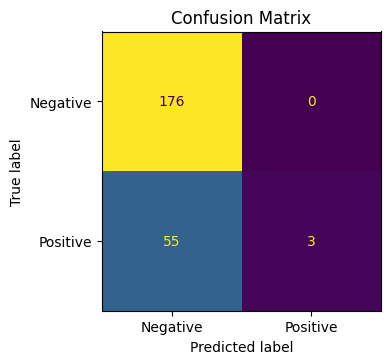

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
)

has_labels = predictions_df["true_label"].notna().any()

if has_labels:
    valid = predictions_df[predictions_df["true_label"].notna()].copy()
    y_true  = valid["true_label"].astype(int)
    y_pred  = valid["predicted_label"].astype(int)
    y_score = valid["prediction_score"].astype(float)

    print("=" * 50)
    print("CLASSIFICATION METRICS")
    print("=" * 50)
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1 Score  : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"ROC AUC   : {roc_auc_score(y_true, y_score):.4f}")
    print(f"PR AUC    : {average_precision_score(y_true, y_score):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(ax=ax, colorbar=False)
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
else:
    print("No true labels found — skipping evaluation.")

## 8. Top Hits

In [16]:
top_hits = (
    predictions_df[predictions_df["predicted_label"] == 1]
    .sort_values("prediction_score", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

n_pos = (predictions_df["predicted_label"] == 1).sum()
print(f"Top 20 predicted positives (out of {n_pos} total predicted positives):")
top_hits[["sample_id", "smiles", "prediction_score", "true_label"]]

Top 20 predicted positives (out of 3 total predicted positives):


,sample_id,smiles,prediction_score,true_label
0,22,Cn1ccnc1C(NC(=O)c1ccc2c(c1)CCCN2S(C)(=O)=O)c1c...,0.950449,1
1,9,Cn1ccnc1C(NC(=O)c1ccc(CNC(N)=O)cc1)c1ccc(Cl)cc1,0.944492,1
2,39,COC(=O)CC(NC(=O)c1cc2c(C)nn(C)c2s1)c1ccc(Cl)cc1,0.628242,1


## 9. Save Hits Above Threshold

In [17]:
SCORE_THRESHOLD = 0.7

hits_df = (
    predictions_df[predictions_df["prediction_score"] >= SCORE_THRESHOLD]
    .sort_values("prediction_score", ascending=False)
    .reset_index(drop=True)
)

hits_path = OUTPUT_PATH.replace(".csv", f"_hits_t{SCORE_THRESHOLD}.csv")
hits_df.to_csv(hits_path, index=False)

print(f"Hits with score >= {SCORE_THRESHOLD}: {len(hits_df)}")
print(f"Saved to: {hits_path}")
hits_df.head()

Hits with score >= 0.7: 2
Saved to: /proj/ligand_ai/users/ozery/mammal_notebook_wdr91_predictions_hits_t0.7.csv


,sample_id,smiles,true_label,predicted_label,prediction_score,raw_score_negative,raw_score_positive
0,22,Cn1ccnc1C(NC(=O)c1ccc2c(c1)CCCN2S(C)(=O)=O)c1c...,1,1,0.950449,0.049550,0.950449
1,9,Cn1ccnc1C(NC(=O)c1ccc(CNC(N)=O)cc1)c1ccc(Cl)cc1,1,1,0.944492,0.055507,0.944492
